###########################################################################################
###########################################################################################
Age group 1: base_age 27–34 (avg of 27–29 & 30–34)
###########################################################################################
###########################################################################################


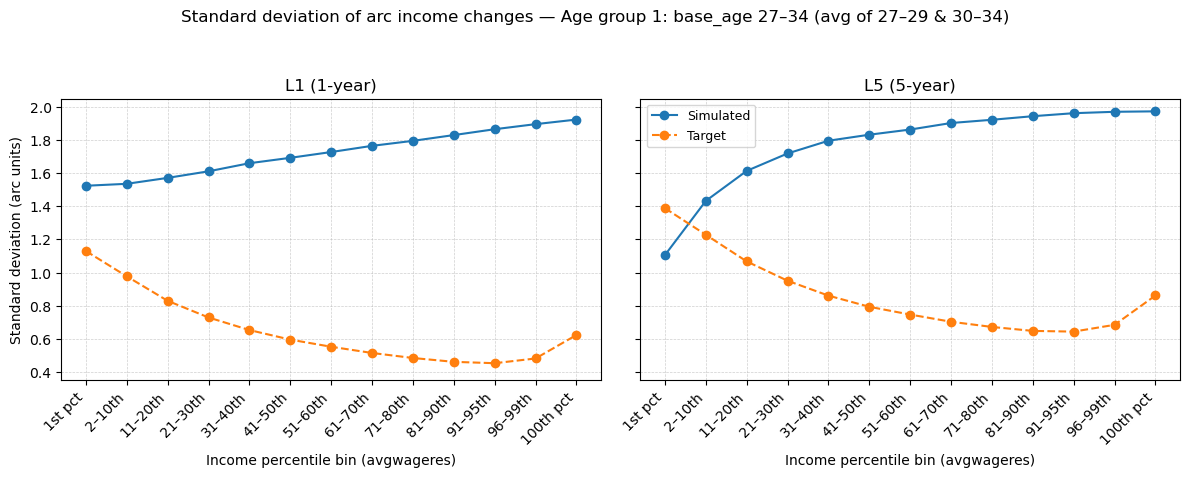

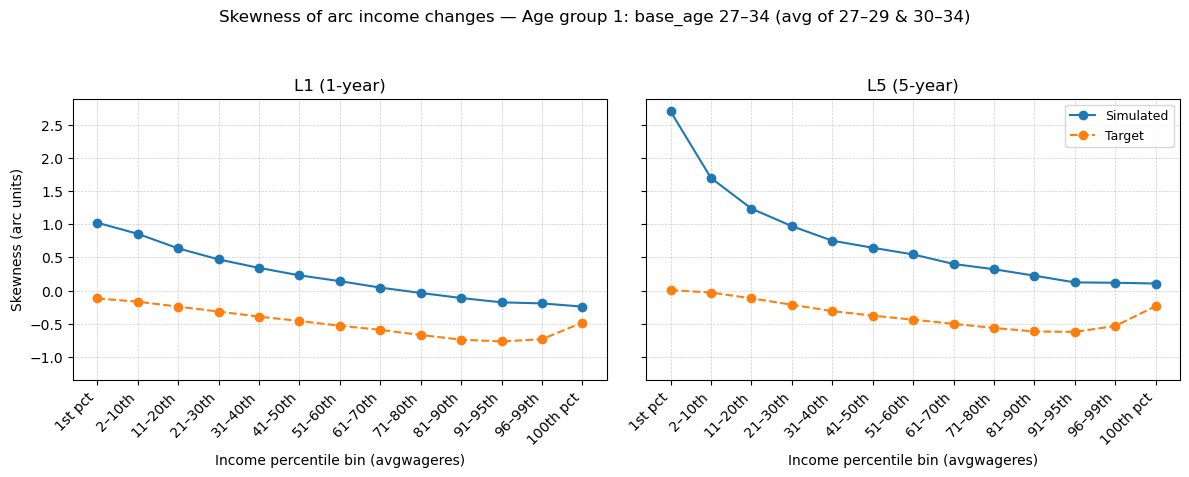

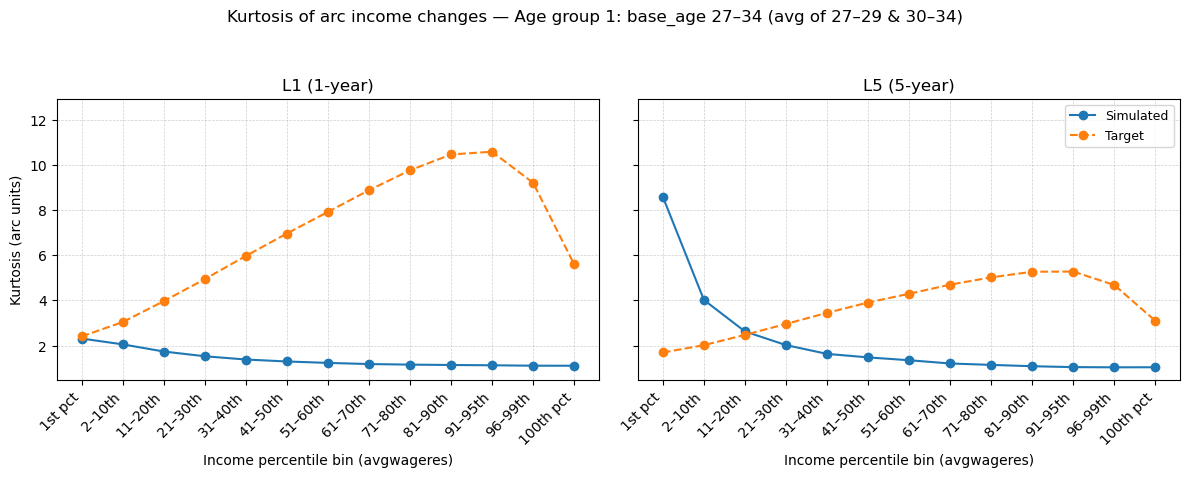

###########################################################################################
###########################################################################################
Age group 2: base_age 33–42 (avg of 33–37 & 38–42)
###########################################################################################
###########################################################################################


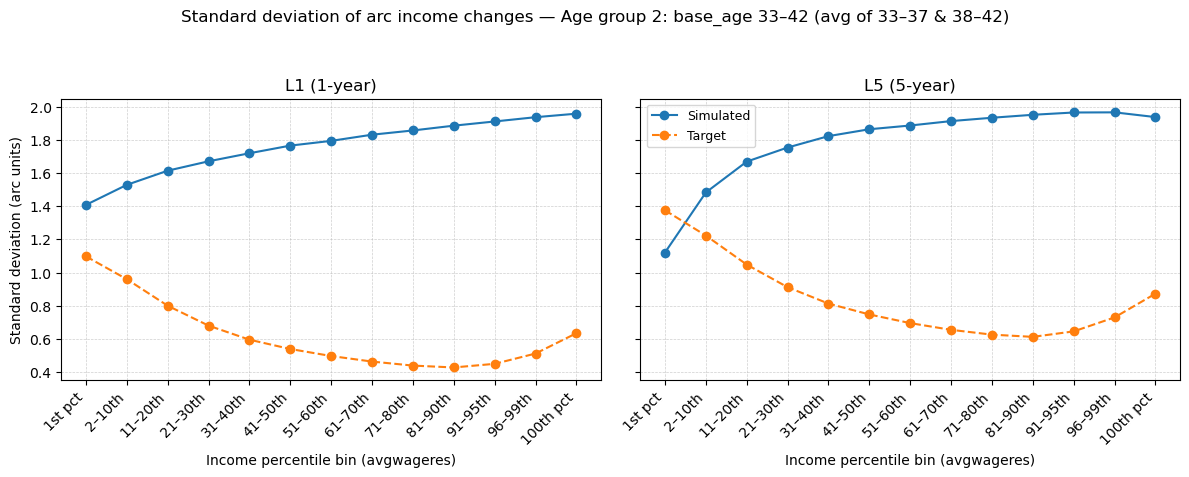

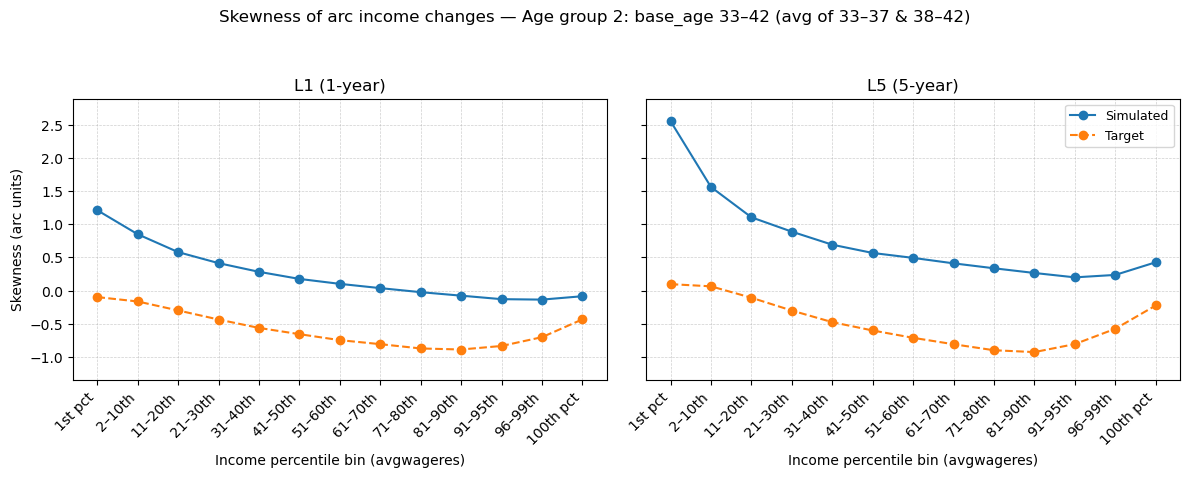

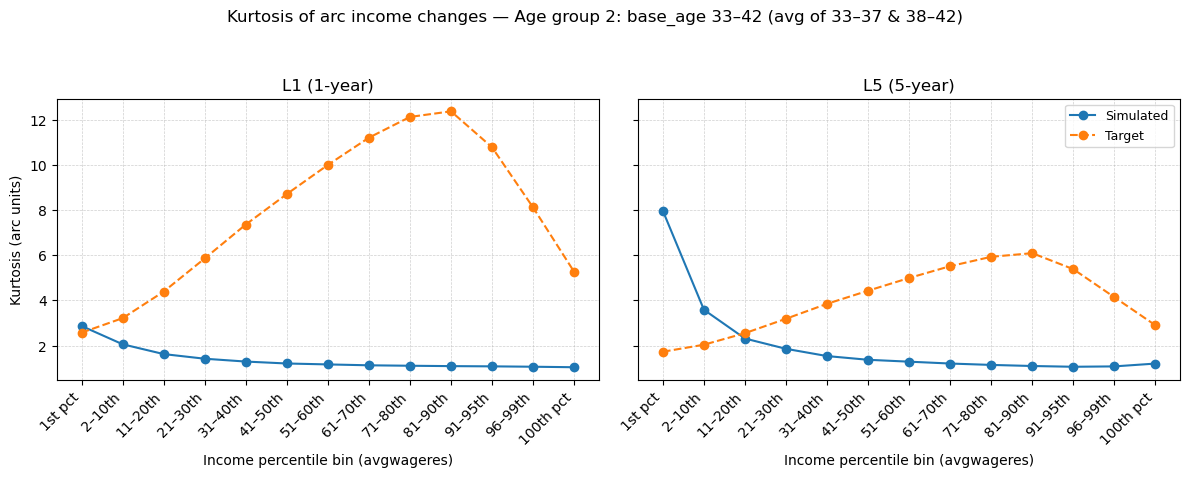

###########################################################################################
###########################################################################################
Age group 3: base_age 43–52 (avg of 43–47 & 48–52)
###########################################################################################
###########################################################################################


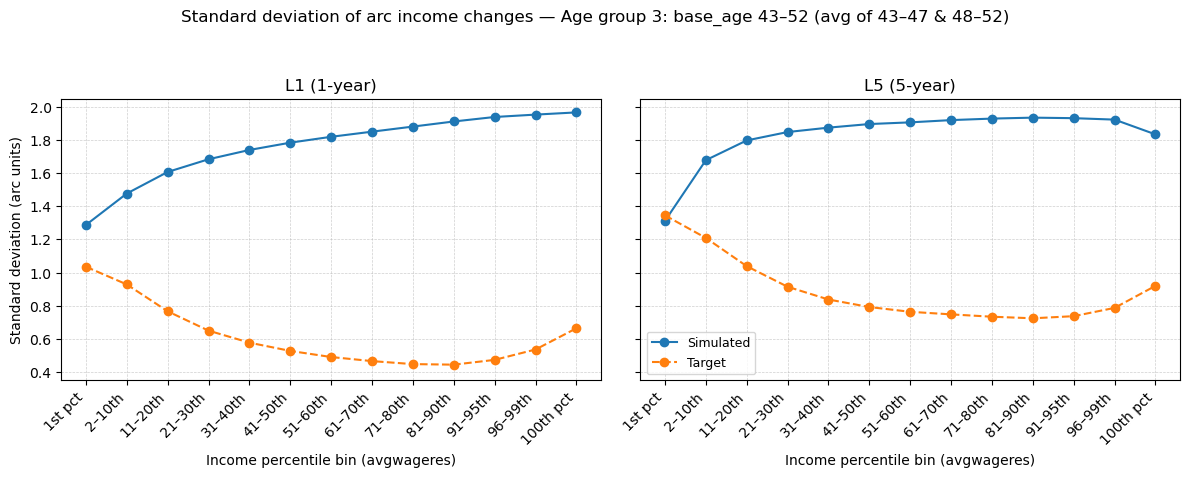

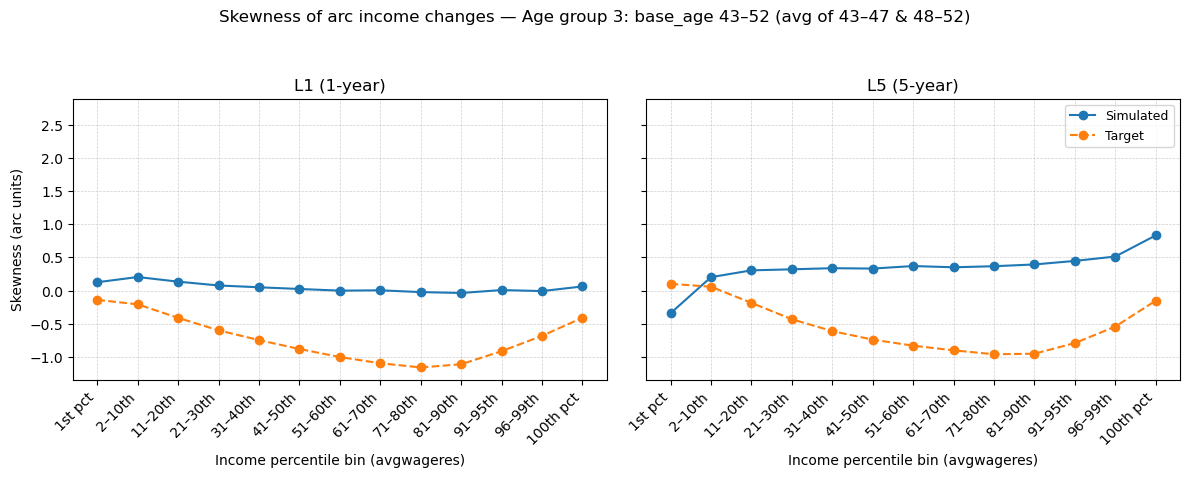

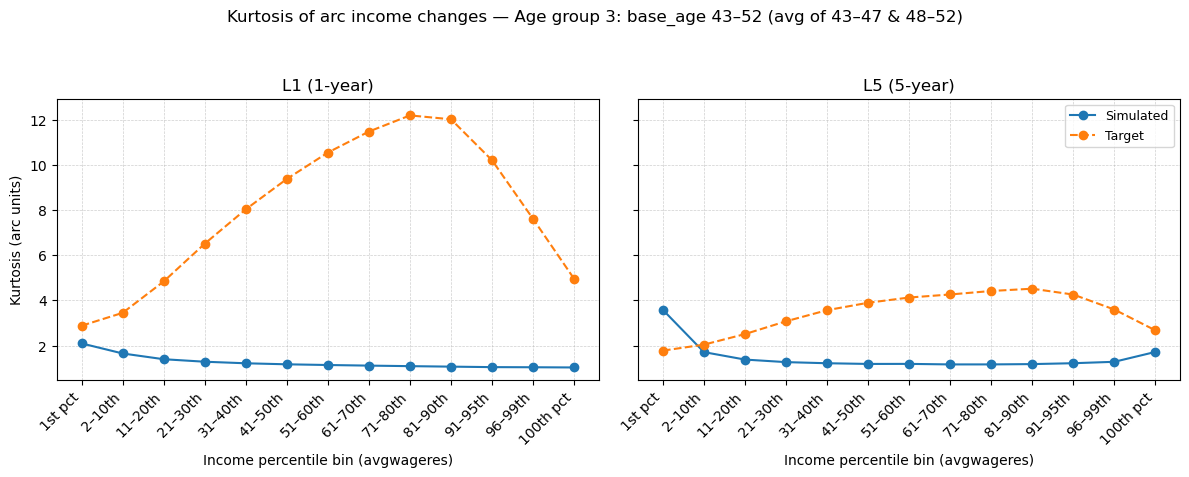

Done (savefig is commented out).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# INPUT
# ----------------------------
path = Path(r"C:\Users\adv23\Dropbox\John-Jackson-Steve 2023\guvenen_2021_replication\targeted_moments_stata\out\sim_cross_vs_target.csv")  # update if needed
df = pd.read_csv(path)
df.columns = [c.strip() for c in df.columns]

# Ensure numeric
for c in ["agegrp", "bin"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# LABELS (from your Stata mapping)
# ----------------------------
agegrp_labels = {
    1: "Age group 1: base_age 27–34 (avg of 27–29 & 30–34)",
    2: "Age group 2: base_age 33–42 (avg of 33–37 & 38–42)",
    3: "Age group 3: base_age 43–52 (avg of 43–47 & 48–52)",
}

# Cross-sectional bins from $PCTLIST:
# "1 2 11 21 31 41 51 61 71 81 91 96 100 101"
bin_labels = {
    1:  "1st pct",
    2:  "2–10th",
    3:  "11–20th",
    4:  "21–30th",
    5:  "31–40th",
    6:  "41–50th",
    7:  "51–60th",
    8:  "61–70th",
    9:  "71–80th",
    10: "81–90th",
    11: "91–95th",
    12: "96–99th",
    13: "100th pct",
}

# ----------------------------
# WHICH MOMENTS TO PLOT
# ----------------------------
moments = [
    ("sd",   "Standard deviation"),
    ("skew", "Skewness"),
    ("kurt", "Kurtosis"),
]

# Column expectations (simulated + target)
# simulated: sd_L1, skew_L1, kurt_L1, sd_L5, ...
# target:    D_sd_L1, D_skew_L1, ... (as in your Stata merge)
required = []
for m, _ in moments:
    required += [f"{m}_L1", f"{m}_L5", f"D_{m}_L1", f"D_{m}_L5"]

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ----------------------------
# PLOTTING
# ----------------------------
bins = list(range(1, 14))
xticks = bins
xticklabels = [bin_labels[b] for b in bins]

# Optional: consistent y-lims within each moment across age groups + L1/L5
# (helps comparability)
def moment_ylim(m):
    cols = [f"{m}_L1", f"D_{m}_L1", f"{m}_L5", f"D_{m}_L5"]
    vals = pd.concat([pd.to_numeric(df[c], errors="coerce") for c in cols], axis=0).dropna()
    if vals.empty:
        return None
    ymin, ymax = vals.min(), vals.max()
    pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
    return ymin - pad, ymax + pad

for ag in sorted(df["agegrp"].dropna().unique()):
    ag_int = int(ag)
    ag_title = agegrp_labels.get(ag_int, f"Age group {ag_int}")
    
    print("###########################################################################################")
    print("###########################################################################################")
    print(ag_title)
    print("###########################################################################################")
    print("###########################################################################################")
    
    sub_ag = df[df["agegrp"] == ag].copy()

    # sort by bin to make lines clean
    sub_ag = sub_ag.sort_values("bin")

    for m, mname in moments:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
        fig.suptitle(f"{mname} of arc income changes — {ag_title}", y=1.05)

        ylims = moment_ylim(m)
        if ylims:
            ymin, ymax = ylims
        else:
            ymin, ymax = None, None

        # ---- Panel 1: L1
        ax = axes[0]
        s = sub_ag.set_index("bin")[f"{m}_L1"].reindex(bins)
        d = sub_ag.set_index("bin")[f"D_{m}_L1"].reindex(bins)

        ax.plot(bins, s.values, marker="o", linewidth=1.5, label="Simulated")
        ax.plot(bins, d.values, marker="o", linewidth=1.5, linestyle="--", label="Target")
        ax.set_title("L1 (1-year)")
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=45, ha="right")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        if ylims:
            ax.set_ylim(ymin, ymax)

        # ---- Panel 2: L5
        ax = axes[1]
        s = sub_ag.set_index("bin")[f"{m}_L5"].reindex(bins)
        d = sub_ag.set_index("bin")[f"D_{m}_L5"].reindex(bins)

        ax.plot(bins, s.values, marker="o", linewidth=1.5, label="Simulated")
        ax.plot(bins, d.values, marker="o", linewidth=1.5, linestyle="--", label="Target")
        ax.set_title("L5 (5-year)")
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=45, ha="right")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        if ylims:
            ax.set_ylim(ymin, ymax)

        # Labels / legend
        axes[0].set_ylabel(f"{mname} (arc units)")
        axes[0].set_xlabel("Income percentile bin (avgwageres)")
        axes[1].set_xlabel("Income percentile bin (avgwageres)")
        axes[1].legend(loc="best", fontsize=9)

        fig.tight_layout()

        # outfile = path.parent / f"{m}_agegrp_{ag_int}_L1_L5.png"
        # fig.savefig(outfile, dpi=200, bbox_inches="tight")  # <-- keep commented for now
        plt.show()

print("Done (savefig is commented out).")
